# Sentiment Analysis using NLP Pipeline & ML Models

## TASK 2

Building an end-to-end sentiment analysis system using NLP preprocessing and machine learning models using 

### Dataset

Dataset used: **IMDb Movie Reviews Dataset**  
Source: https:https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

#### Note

Dataset is not included in the repository due to size constraints.  
Please download it from the Kaggle link

In [1]:
#Imports
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tanisha/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /Users/tanisha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("IMDB_Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Dataset Info

In [4]:

print("shape of data:", df.shape)

print("\ncolumns:")
print(df.columns)

print("\ndata types:")
print(df.dtypes)

print("\nnull values:")
print(df.isnull().sum())

print("\nbasic info:")
df.info()

print("\nsample rows:")
print(df.sample(5))

shape of data: (50000, 2)

columns:
Index(['review', 'sentiment'], dtype='object')

data types:
review       object
sentiment    object
dtype: object

null values:
review       0
sentiment    0
dtype: int64

basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

sample rows:
                                                  review sentiment
42493  Very slow, dull, enigmatic film. MAybe the kin...  negative
40085  Many things become clear when watching this fi...  negative
46327  I got the DVD from the library in the expectat...  negative
9204   I couldn't' agree more than with the comment l...  positive
25413  I went and saw this movie last night after bei...  positive


## Preprocessing Dataset

In [9]:
# creating stopword set and lemmatizer
sw = set(stopwords.words('english'))
lem = WordNetLemmatizer()
def clean_txt(txt):
    
    if not txt or not isinstance(txt, str):
        return ""
    
    # lower
    txt = txt.lower()
    
    # remove urls
    txt = re.sub(r'http\S+|www\S+', '', txt)
    txt = re.sub(r'<.*?>', '', txt)
    
    # remove special chars
    txt = re.sub(r'[^a-z\s]', '', txt)
    
    # remove extra spaces
    txt = re.sub(r'\s+', ' ', txt).strip()
    
    # tokenize
    tok = txt.split()
    
    # remove stopwords
    tok = [w for w in tok if w not in sw]
    
    # lemmatize
    tok = [lem.lemmatize(w) for w in tok]
    
    return " ".join(tok)
print("\ncleaning done: text simplified and noise removed")
# applying cleaning to dataset

df['clean'] = df['review'].apply(clean_txt)

df[['review', 'clean']].head()


cleaning done: text simplified and noise removed


,review,clean
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [10]:
# checking few cleaned samples

for i in range(3):
    print("\noriginal:", df['review'][i][:200])
    print("cleaned :", df['clean'][i][:200])


original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
cleaned : one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pu

original: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece
cleaned : wonderful little production filming technique unassuming oldtimebbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen got polari voic

original: I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-heart

## Feature Engineering

In [11]:
# splitting data

x = df['clean']
y = df['sentiment']

from sklearn.model_selection import train_test_split

x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)

print("train:", x_tr.shape)
print("test :", x_te.shape)

train: (40000,)
test : (10000,)


In [12]:
print("x train:", x_tr.shape)
print("x test :", x_te.shape)
print("y train:", y_tr.shape)
print("y test :", y_te.shape)
print("\ndata split done (80-20)")
df['sentiment'].value_counts()

x train: (40000,)
x test : (10000,)
y train: (40000,)
y test : (10000,)

data split done (80-20)


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

### Bag of Words

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

x_tr_bow = cv.fit_transform(x_tr)
x_te_bow = cv.transform(x_te)

print("\nbag of words ready:", x_tr_bow.shape)


bag of words ready: (40000, 175685)


### TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer()

x_tr_tf = tf.fit_transform(x_tr)
x_te_tf = tf.transform(x_te)

print("\ntfidf ready:", x_tr_tf.shape)


tfidf ready: (40000, 175685)


In [16]:
# checking some words

print("\nsample bow words:")
print(cv.get_feature_names_out()[:10])

print("\nsample tfidf words:")
print(tf.get_feature_names_out()[:10])


sample bow words:
['aa' 'aaa' 'aaaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' 'aaaaaaaargh' 'aaaaagh'
 'aaaaah' 'aaaaargh' 'aaaaatchkah' 'aaaaaw']

sample tfidf words:
['aa' 'aaa' 'aaaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' 'aaaaaaaargh' 'aaaaagh'
 'aaaaah' 'aaaaargh' 'aaaaatchkah' 'aaaaaw']


## Model Building
#### Using:
1. Logistic Regression
2. Naive Bayes
3. Decision Tree

### Logistic Regression


In [20]:

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_tr_tf, y_tr)

y_lr = lr.predict(x_te_tf)

print("\nlogistic model trained")

from sklearn.metrics import accuracy_score

# quick performance check
acc_lr = accuracy_score(y_te, y_lr)

print("\nlogistic model trained")
print("acc:", round(acc_lr, 4))

# small before vs after view
print("\nsample predictions:")
for i in range(3):
    print("pred:", y_lr[i], "| actual:", y_te.iloc[i])


logistic model trained

logistic model trained
acc: 0.8941

sample predictions:
pred: negative | actual: positive
pred: positive | actual: positive
pred: negative | actual: negative


### Naive Bayes 

In [34]:


from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(x_tr_bow, y_tr)

y_nb = nb.predict(x_te_bow)

print("\nnaive bayes model trained")
from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_te, y_nb)

print("acc:", round(acc_nb, 4))

print("\nsample predictions:")
for i in range(3):
    print("pred:", y_nb[i], "| actual:", y_te.iloc[i])



naive bayes model trained
acc: 0.8597

sample predictions:
pred: positive | actual: positive
pred: positive | actual: positive
pred: negative | actual: negative


### Decision Tree

In [22]:


from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(x_tr_tf, y_tr)

y_dt = dt.predict(x_te_tf)

print("\ndecision tree model trained")

from sklearn.metrics import accuracy_score

acc_dt = accuracy_score(y_te, y_dt)

print("\ndecision tree model trained")
print("acc:", round(acc_dt, 4))

print("\nsample predictions:")
for i in range(3):
    print("pred:", y_dt[i], "| actual:", y_te.iloc[i])


decision tree model trained

decision tree model trained
acc: 0.7161

sample predictions:
pred: negative | actual: positive
pred: negative | actual: positive
pred: negative | actual: negative


## Classification Report

In [38]:
# evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_mod(y_t, y_p, name):
    
    acc = accuracy_score(y_t, y_p)
    prec = precision_score(y_t, y_p, average='weighted')
    rec = recall_score(y_t, y_p, average='weighted')
    f1 = f1_score(y_t, y_p, average='weighted')
    
    print(f"\n{name}")
    print("acc :", round(acc, 4))
    print("prec:", round(prec, 4))
    print("rec :", round(rec, 4))
    print("f1  :", round(f1, 4))
    
    return acc, prec, rec, f1
res = []

res.append(eval_mod(y_te, y_lr, "logistic regression"))
res.append(eval_mod(y_te, y_nb, "naive bayes"))
res.append(eval_mod(y_te, y_dt, "decision tree"))


logistic regression
acc : 0.8941
prec: 0.8944
rec : 0.8941
f1  : 0.8941

naive bayes
acc : 0.8597
prec: 0.8601
rec : 0.8597
f1  : 0.8597

decision tree
acc : 0.7161
prec: 0.7162
rec : 0.7161
f1  : 0.7161


## Comparitive Table

In [40]:
import pandas as pd

comp = pd.DataFrame(res, columns=['acc', 'prec', 'rec', 'f1'])
comp['model'] = ['logistic regression', 'naive bayes', 'decision tree']

comp = comp[['model', 'acc', 'prec', 'rec', 'f1']]

comp


,model,acc,prec,rec,f1
0,logistic regression,0.8941,0.894357,0.8941,0.894070
1,naive bayes,0.8597,0.860070,0.8597,0.859684
2,decision tree,0.7161,0.716196,0.7161,0.716099


## Comparitive Graph

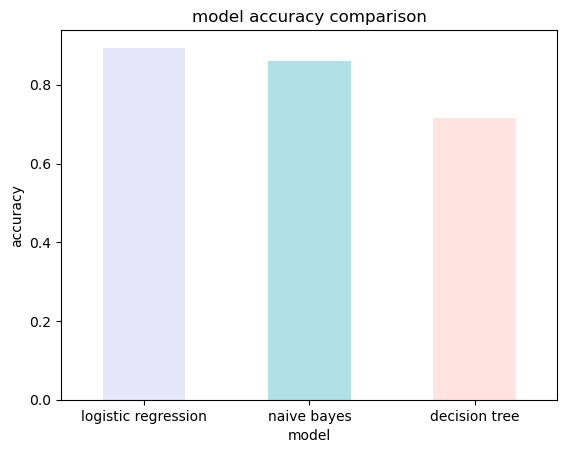

In [41]:
import matplotlib.pyplot as plt

comp.set_index('model')['acc'].plot(
    kind='bar',
    color=['lavender', 'powderblue', 'mistyrose']
)

plt.title("model accuracy comparison")
plt.ylabel("accuracy")
plt.xticks(rotation=0)

plt.show()